In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
import os
warnings.filterwarnings("ignore")

In [5]:
df = pd.read_csv("data_with_weather.csv", parse_dates=["datetime"])
df = df.sort_values("datetime").reset_index(drop=True)

print("=== Dataset Info ===")
print(f"Shape        : {df.shape}")
print(f"Date range   : {df['datetime'].min()} → {df['datetime'].max()}")
print(f"Missing vals :\n{df.isnull().sum()}")
print(f"\nDemand stats :\n{df['demand'].describe()}")

=== Dataset Info ===
Shape        : (28416, 13)
Date range   : 2020-03-04 03:00:00 → 2023-06-01 02:00:00
Missing vals :
datetime       0
demand         0
hour           0
day_of_week    0
is_weekend     0
event          0
temp           0
feelslike      0
precip         0
snow           0
snowdepth      0
is_snowing     0
is_raining     0
dtype: int64

Demand stats :
count     28416.000000
mean      13604.210058
std       19733.731770
min           0.000000
25%           0.000000
50%         604.000000
75%       24905.000000
max      193464.000000
Name: demand, dtype: float64


In [6]:
def engineer_features(df):
    df = df.copy()

    # -- Time features --
    df["month"]            = df["datetime"].dt.month
    df["week_of_year"]     = df["datetime"].dt.isocalendar().week.astype(int)
    df["day_of_month"]     = df["datetime"].dt.day
    df["is_morning_peak"]  = ((df["hour"] >= 7)  & (df["hour"] <= 9)).astype(int)
    df["is_evening_peak"]  = ((df["hour"] >= 16) & (df["hour"] <= 18)).astype(int)
    df["is_midday"]        = ((df["hour"] >= 11) & (df["hour"] <= 14)).astype(int)
    df["is_late_night"]    = ((df["hour"] >= 22) | (df["hour"] <= 5)).astype(int)

    # Cyclical encoding — captures that hour 23 and hour 0 are close, not far apart
    df["hour_sin"]   = np.sin(2 * np.pi * df["hour"]        / 24)
    df["hour_cos"]   = np.cos(2 * np.pi * df["hour"]        / 24)
    df["dow_sin"]    = np.sin(2 * np.pi * df["day_of_week"] / 7)
    df["dow_cos"]    = np.cos(2 * np.pi * df["day_of_week"] / 7)
    df["month_sin"]  = np.sin(2 * np.pi * df["month"]       / 12)
    df["month_cos"]  = np.cos(2 * np.pi * df["month"]       / 12)

    # -- Weather features --
    df["feels_cold"]       = (df["feelslike"] < 32).astype(int)
    df["feels_very_cold"]  = (df["feelslike"] < 20).astype(int)
    df["heavy_snow"]       = (df["snowdepth"] > 3).astype(int)
    df["bad_weather"]      = (df["is_snowing"] | df["is_raining"]).astype(int)
    df["cold_and_snowing"] = (df["feels_cold"] & df["is_snowing"]).astype(int)
    df["temp_x_hour"]      = df["temp"] * df["hour"]   # interaction term

    # -- Lag features (past demand) --
    # Gives XGBoost temporal context, similar to how LSTM uses sequences
    for lag in [1, 2, 3, 24, 48, 168]:    # 1-3 hrs, yesterday, 2 days, 1 week ago
        df[f"demand_lag_{lag}"] = df["demand"].shift(lag)

    # -- Rolling window statistics --
    df["demand_roll_mean_3h"]  = df["demand"].shift(1).rolling(3).mean()
    df["demand_roll_mean_24h"] = df["demand"].shift(1).rolling(24).mean()
    df["demand_roll_std_24h"]  = df["demand"].shift(1).rolling(24).std()
    df["demand_roll_max_24h"]  = df["demand"].shift(1).rolling(24).max()

    # Drop rows with NaN from lags
    df = df.dropna().reset_index(drop=True)
    return df


df_feat = engineer_features(df)
print(f"\nAfter feature engineering: {df_feat.shape}")


After feature engineering: (28248, 42)


In [20]:
FEATURE_COLS = [
    "demand",
    # Raw time
    "hour", "day_of_week", "is_weekend", "month", "week_of_year", "day_of_month",
    # Peak flags
    "is_morning_peak", "is_evening_peak", "is_midday", "is_late_night",
    # Cyclical encodings
    "hour_sin", "hour_cos", "dow_sin", "dow_cos", "month_sin", "month_cos",
    # Weather
    "temp", "feelslike", "precip", "snow", "snowdepth", "is_snowing", "is_raining",
    # Weather interactions
    "feels_cold", "feels_very_cold", "heavy_snow", "bad_weather",
    "cold_and_snowing", "temp_x_hour",
    # Events
    "event",
    # Lag features
    "demand_lag_1", "demand_lag_2", "demand_lag_3",
    "demand_lag_24", "demand_lag_48", "demand_lag_168",
    # Rolling stats
    "demand_roll_mean_3h", "demand_roll_mean_24h",
    "demand_roll_std_24h", "demand_roll_max_24h",
]

TARGET = "demand"

X = df_feat[FEATURE_COLS]
y = df_feat[TARGET]

In [8]:
split_idx = int(len(df_feat) * 0.80)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"\nTrain size : {len(X_train)}")
print(f"Test  size : {len(X_test)}")
print(f"Train dates: {df_feat['datetime'].iloc[0]} → {df_feat['datetime'].iloc[split_idx-1]}")
print(f"Test  dates: {df_feat['datetime'].iloc[split_idx]} → {df_feat['datetime'].iloc[-1]}")


Train size : 22598
Test  size : 5650
Train dates: 2020-03-11 03:00:00 → 2022-10-08 16:00:00
Test  dates: 2022-10-08 17:00:00 → 2023-06-01 02:00:00


In [9]:
model = XGBRegressor(
    n_estimators          = 500,
    learning_rate         = 0.05,
    max_depth             = 6,
    min_child_weight      = 5,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    reg_alpha             = 0.1,
    reg_lambda            = 1.0,
    early_stopping_rounds = 30,
    eval_metric           = "rmse",
    random_state          = 42,
    n_jobs                = -1,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

[0]	validation_0-rmse:27039.69668
[50]	validation_0-rmse:3549.36398
[100]	validation_0-rmse:2521.94800
[142]	validation_0-rmse:2538.88233


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=30,
             enable_categorical=False, eval_metric='rmse', feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=5, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=-1, num_parallel_tree=None, ...)

In [10]:
y_pred = model.predict(X_test)
y_pred = np.maximum(y_pred, 0)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / (y_test + 1e-8))) * 100

print("\n" + "="*45)
print("       XGBoost — TEST SET METRICS")
print("="*45)
print(f"  RMSE : {rmse}")
print(f"  MAE  : {mae}")
print(f"  R²   : {r2}")
print(f"  MAPE : {mape}%")
print("="*45)


       XGBoost — TEST SET METRICS
  RMSE : 2502.149775692894
  MAE  : 566.3274536132812
  R²   : 0.9877986907958984
  MAPE : 15912431297.102428%


In [11]:
print("\nRunning 5-fold TimeSeriesSplit cross-validation...")
tscv = TimeSeriesSplit(n_splits=5)

cv_model = XGBRegressor(
    n_estimators=300, learning_rate=0.05, max_depth=6,
    min_child_weight=5, subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1
)

X = df_feat[FEATURE_COLS]
y = df_feat[TARGET]

cv_rmse_scores = []
for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
    X_cv_train, X_cv_val = X.iloc[train_idx], X.iloc[val_idx]
    y_cv_train, y_cv_val = y.iloc[train_idx], y.iloc[val_idx]
    cv_model.fit(X_cv_train, y_cv_train, verbose=False)
    preds     = cv_model.predict(X_cv_val)
    fold_rmse = np.sqrt(mean_squared_error(y_cv_val, preds))
    cv_rmse_scores.append(fold_rmse)
    print(f"  Fold {fold+1} RMSE: {fold_rmse}")

print(f"\n  Mean CV RMSE : {np.mean(cv_rmse_scores)}")
print(f"  Std  CV RMSE : {np.std(cv_rmse_scores)}")


Running 5-fold TimeSeriesSplit cross-validation...
  Fold 1 RMSE: 147.56629204149232
  Fold 2 RMSE: 4247.55529687372
  Fold 3 RMSE: 1663.751859503093
  Fold 4 RMSE: 2086.090002852226
  Fold 5 RMSE: 2224.239195770095

  Mean CV RMSE : 2073.8405294081253
  Std  CV RMSE : 1313.5075830362005


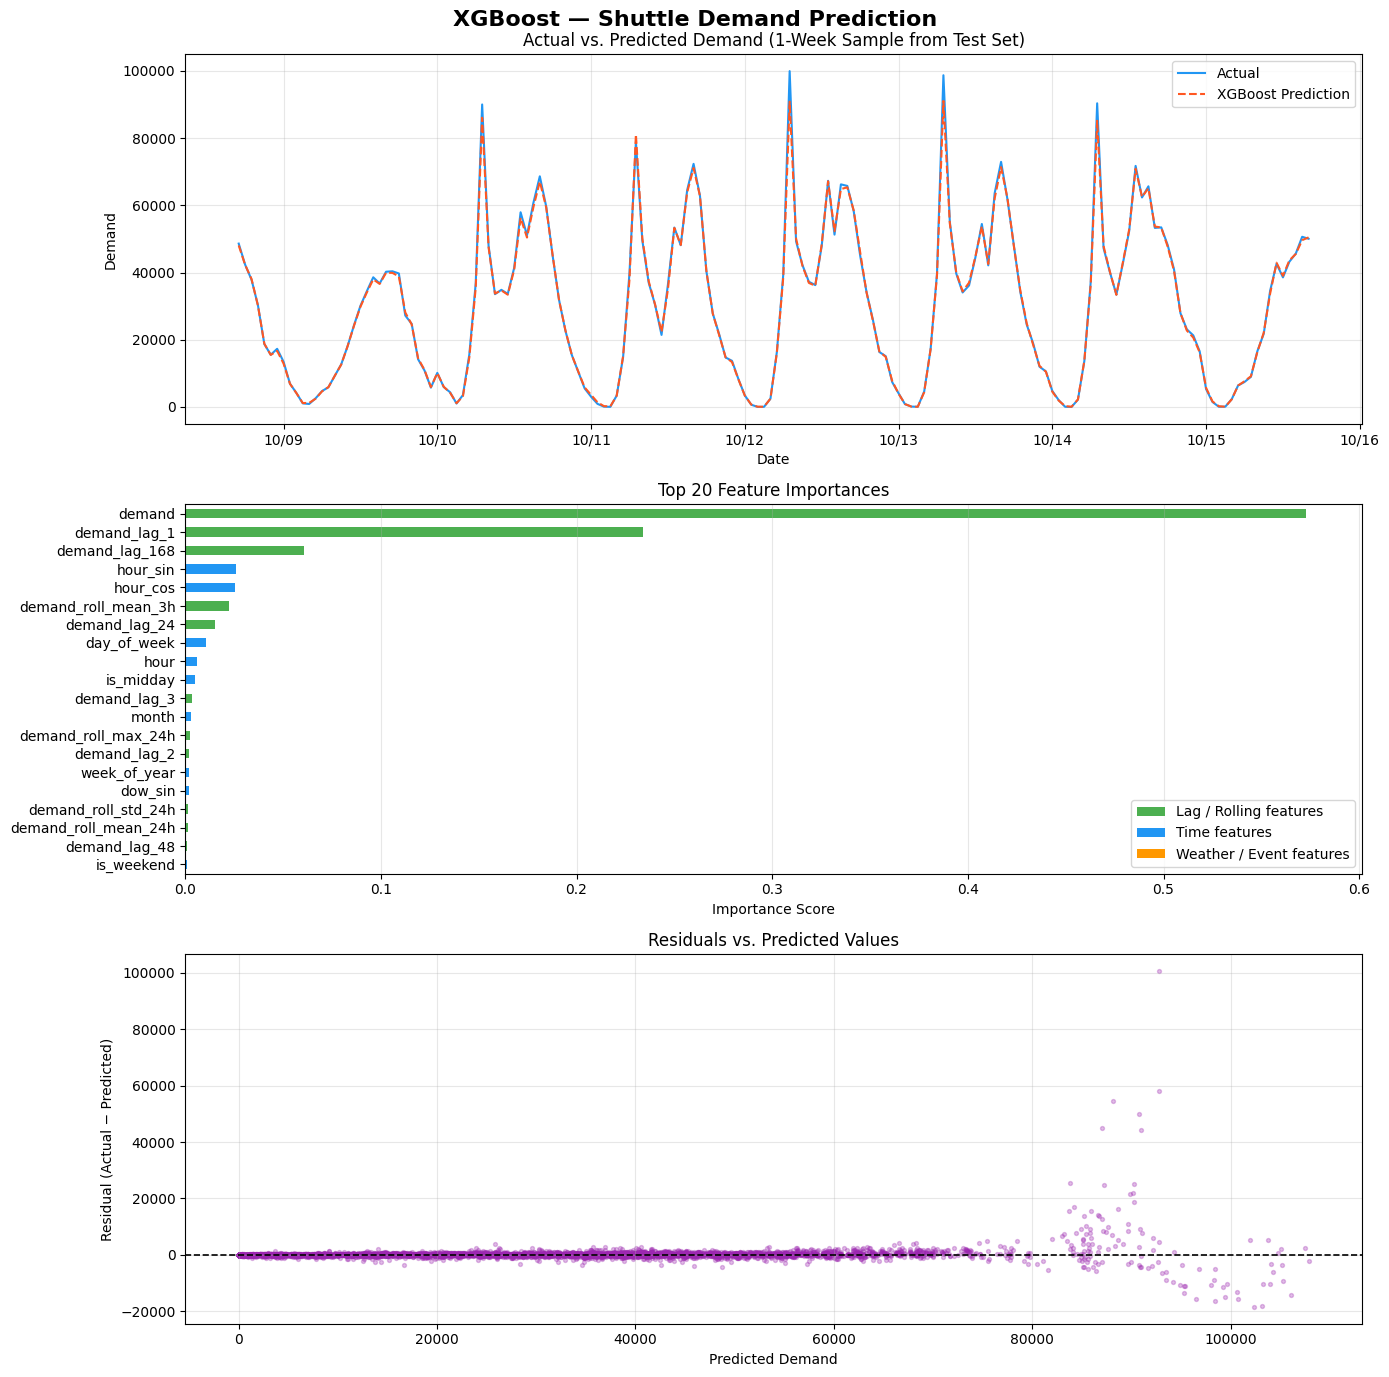


Plot saved → xgboost_results.png


In [12]:
fig, axes = plt.subplots(3, 1, figsize=(14, 14))
fig.suptitle("XGBoost — Shuttle Demand Prediction", fontsize=16, fontweight="bold")

ax = axes[0]
sample_dates = df_feat["datetime"].iloc[split_idx : split_idx + 168]
ax.plot(sample_dates, y_test.values[:168], label="Actual",
        color="#2196F3", linewidth=1.5)
ax.plot(sample_dates, y_pred[:168],        label="XGBoost Prediction",
        color="#FF5722", linewidth=1.5, linestyle="--")
ax.set_title("Actual vs. Predicted Demand (1-Week Sample from Test Set)")
ax.set_xlabel("Date")
ax.set_ylabel("Demand")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m/%d"))
ax.grid(alpha=0.3)

ax = axes[1]
importance = pd.Series(model.feature_importances_, index=FEATURE_COLS)
top20 = importance.nlargest(20)

def get_color(f):
    if "demand" in f: return "#4CAF50"
    if any(t in f for t in ["hour","dow","month","week","day","peak","midday","night"]):
        return "#2196F3"
    return "#FF9800"

colors = [get_color(f) for f in top20.sort_values().index]
top20.sort_values().plot(kind="barh", ax=ax, color=colors)
ax.set_title("Top 20 Feature Importances")
ax.set_xlabel("Importance Score")
ax.grid(axis="x", alpha=0.3)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor="#4CAF50", label="Lag / Rolling features"),
    Patch(facecolor="#2196F3", label="Time features"),
    Patch(facecolor="#FF9800", label="Weather / Event features"),
], loc="lower right")


ax = axes[2]
residuals = y_test.values - y_pred
ax.scatter(y_pred, residuals, alpha=0.3, s=8, color="#9C27B0")
ax.axhline(0, color="black", linewidth=1.2, linestyle="--")
ax.set_title("Residuals vs. Predicted Values")
ax.set_xlabel("Predicted Demand")
ax.set_ylabel("Residual (Actual − Predicted)")
ax.grid(alpha=0.3)

plt.tight_layout()
os.makedirs('../../Graphs', exist_ok=True)
plt.savefig("../../Graphs/xgboost_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nPlot saved → xgboost_results.png")

In [19]:
print("\n=== Weather Impact on Demand (Test Set) ===")
test_df = df_feat.iloc[split_idx:].copy()
test_df["predicted"] = y_pred

conditions = {
    "Snowing"        : test_df["is_snowing"]  == 1,
    "Raining"        : test_df["is_raining"]  == 1,
    "Below Freezing" : test_df["feelslike"]   <  32,
    "Event Day"      : test_df["event"]       == 1,
    "Clear / Normal" : test_df["bad_weather"] == 0,
}

for label, mask in conditions.items():
    subset = test_df[mask]
    if len(subset) > 0:
        print(f"  {label:<20}: "
              f"Actual = {subset['demand'].mean():>8,.0f} | "
              f"Predicted = {subset['predicted'].mean():>8,.0f} | "
              f"n = {len(subset)}")


=== Weather Impact on Demand (Test Set) ===
  Below Freezing      : Actual =   27,321 | Predicted =   27,195 | n = 5650
  Event Day           : Actual =   26,916 | Predicted =   26,745 | n = 580
  Clear / Normal      : Actual =   27,321 | Predicted =   27,195 | n = 5650


=== Simulated RIT Shuttle Demand ===
Mean demand/hr : 96.5 passengers
Max  demand/hr : 272 passengers
Min  demand/hr (service hours): 6 passengers

Heuristic — frequency distribution:
  0 overnight (no service): 49 hours (29.2%)
  1 bus(es): 32 hours (19.0%)
  2 bus(es): 23 hours (13.7%)
  3 bus(es): 32 hours (19.0%)
  4 bus(es): 32 hours (19.0%)

Optimization — frequency distribution:
  0 overnight (no service): 49 hours (29.2%)
  1 bus(es): 32 hours (19.0%)
  2 bus(es): 23 hours (13.7%)
  3 bus(es): 32 hours (19.0%)
  4 bus(es): 32 hours (19.0%)

=== Fixed Baseline (2 buses always) ===
  Total buses deployed  : 238
  Avg buses / hour      : 2.00
  Total unmet demand    : 4280 passengers
  Avg utilization rate  : 75.7%
  Operational cost      : 11,900 units
  Wait cost             : 428,000 units
  Total cost C          : 439,900 units

=== Heuristic Scheduling ===
  Total buses deployed  : 302
  Avg buses / hour      : 2.54
  Total unmet demand    : 1384 passengers
  Avg utilization 

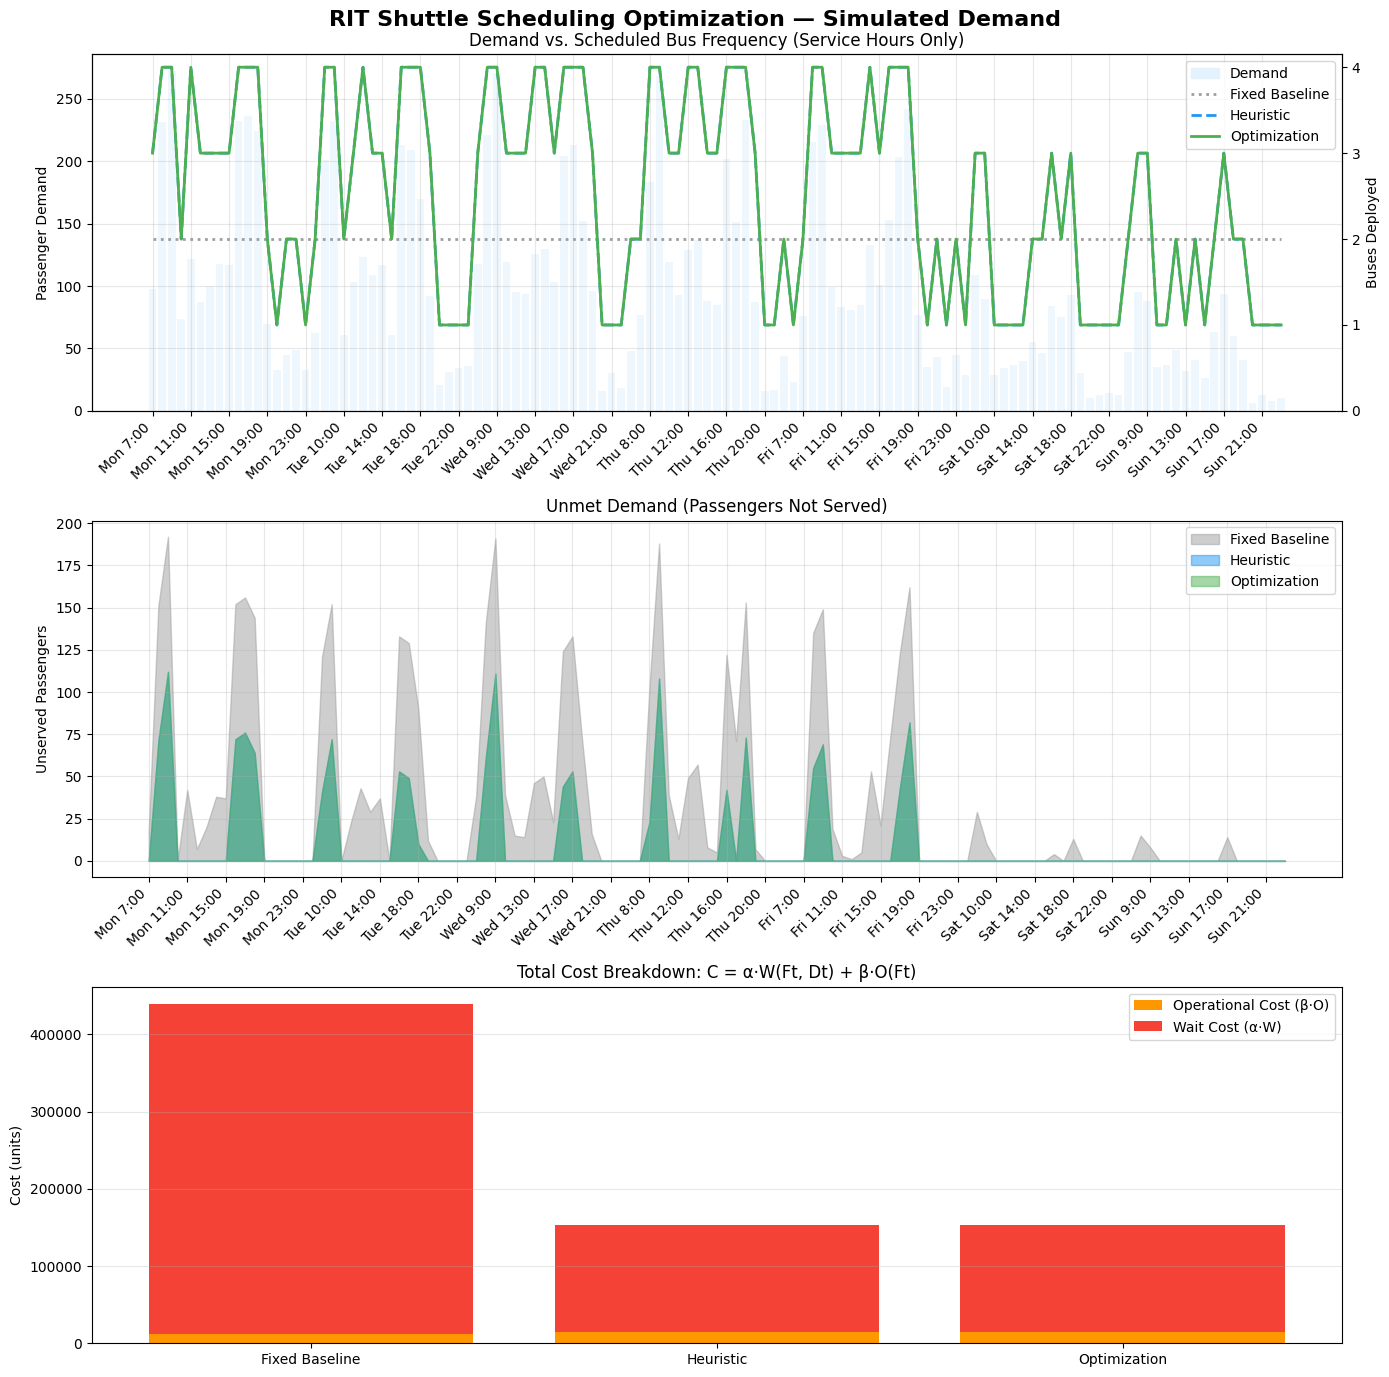


Peak vs. Off-Peak Breakdown:
              Avg_Demand  Fixed_Unmet  Heuristic_Unmet  Optimized_Unmet  Fixed_Avg_Buses  Heuristic_Avg_Buses  Optimized_Avg_Buses
period                                                                                                                            
Evening Peak      166.95         1868              661              661              2.0                 3.57                 3.57
Late Night         28.14            0                0                0              2.0                 1.29                 1.29
Morning Peak      193.21         1585              723              723              2.0                 3.71                 3.71
Off-Peak           69.74          827                0                0              2.0                 2.24                 2.24


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

np.random.seed(42)

hours = np.arange(24)
days  = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

def simulate_hourly_demand(hour, is_weekend):
    if hour < 7 or hour > 23:
        return 0
    if is_weekend:
        base = 20
    else:
        base = 50

    if 8 <= hour <= 9:
        demand = np.random.randint(180, 280)

    elif 16 <= hour <= 18:
        demand = np.random.randint(150, 250)

    elif 11 <= hour <= 14:
        demand = np.random.randint(80, 140)

    elif 7 <= hour <= 10 or 15 <= hour <= 19:
        demand = np.random.randint(60, 120)

    else:
        demand = np.random.randint(10, 50)

    if is_weekend:
        demand = int(demand * 0.4)

    return max(0, demand)

records = []
for day_idx, day in enumerate(days):
    is_weekend = day_idx >= 5
    for hour in hours:
        demand = simulate_hourly_demand(hour, is_weekend)
        records.append({'day': day, 'hour': hour,
                        'is_weekend': is_weekend, 'demand': demand})

sim_df = pd.DataFrame(records)

print('=== Simulated RIT Shuttle Demand ===')
print(f'Mean demand/hr : {sim_df[sim_df["demand"]>0]["demand"].mean():.1f} passengers')
print(f'Max  demand/hr : {sim_df["demand"].max()} passengers')
print(f'Min  demand/hr (service hours): {sim_df[sim_df["demand"]>0]["demand"].min()} passengers')


BUS_CAPACITY       = 40
COST_PER_BUS       = 50
WAIT_COST_PER_PASS = 10
FIXED_FREQUENCY    = 2
MIN_BUSES          = 1
MAX_BUSES          = 4
ALPHA              = 10
BETA               = 1


sim_df['fixed_freq'] = sim_df['demand'].apply(
    lambda d: FIXED_FREQUENCY if d > 0 else 0
)


HEURISTIC_THRESHOLDS = [
    (0,   0),
    (1,   1),
    (40,  2),
    (80,  3),
    (120, 4),
]

def heuristic_schedule(demand):
    if demand == 0:
        return 0
    buses = 1
    for threshold, n_buses in HEURISTIC_THRESHOLDS:
        if demand > threshold:
            buses = n_buses
    return min(buses, MAX_BUSES)

sim_df['heuristic_freq'] = sim_df['demand'].apply(heuristic_schedule)


def optimization_schedule(demand):
    if demand == 0:
        return 0
    best_freq = 1
    best_cost = float('inf')
    for f in range(MIN_BUSES, MAX_BUSES + 1):
        unmet      = max(0, demand - f * BUS_CAPACITY)
        wait_cost  = ALPHA * WAIT_COST_PER_PASS * unmet
        ops_cost   = BETA  * COST_PER_BUS * f
        total_cost = wait_cost + ops_cost
        if total_cost < best_cost:
            best_cost = total_cost
            best_freq = f
    return best_freq

sim_df['optimized_freq'] = sim_df['demand'].apply(optimization_schedule)

print('\nHeuristic — frequency distribution:')
unique, counts = np.unique(sim_df['heuristic_freq'], return_counts=True)
for u, c in zip(unique, counts):
    label = 'overnight (no service)' if u == 0 else 'bus(es)'
    print(f'  {int(u)} {label}: {c} hours ({100*c/len(sim_df):.1f}%)')

print('\nOptimization — frequency distribution:')
unique, counts = np.unique(sim_df['optimized_freq'], return_counts=True)
for u, c in zip(unique, counts):
    label = 'overnight (no service)' if u == 0 else 'bus(es)'
    print(f'  {int(u)} {label}: {c} hours ({100*c/len(sim_df):.1f}%)')


def evaluate_schedule(freq_col, label):
    service_hours = sim_df[sim_df['demand'] > 0].copy()
    freq  = service_hours[freq_col].values
    demand = service_hours['demand'].values
    capacity  = freq * BUS_CAPACITY
    unmet     = np.maximum(0, demand - capacity)
    util      = np.minimum(demand, capacity) / np.maximum(capacity, 1)
    wait_cost = ALPHA * WAIT_COST_PER_PASS * unmet.sum()
    ops_cost  = BETA  * COST_PER_BUS * freq.sum()
    total     = wait_cost + ops_cost

    print(f'\n=== {label} ===')
    print(f'  Total buses deployed  : {freq.sum()}')
    print(f'  Avg buses / hour      : {freq.mean():.2f}')
    print(f'  Total unmet demand    : {unmet.sum():.0f} passengers')
    print(f'  Avg utilization rate  : {util.mean()*100:.1f}%')
    print(f'  Operational cost      : {ops_cost:,.0f} units')
    print(f'  Wait cost             : {wait_cost:,.0f} units')
    print(f'  Total cost C          : {total:,.0f} units')

    return {
        'label': label, 'buses': freq.sum(),
        'unmet': unmet.sum(), 'utilization': util.mean()*100,
        'ops_cost': ops_cost, 'wait_cost': wait_cost, 'total_cost': total,
    }

res_fixed = evaluate_schedule('fixed_freq',     'Fixed Baseline (2 buses always)')
res_heur  = evaluate_schedule('heuristic_freq', 'Heuristic Scheduling')
res_opt   = evaluate_schedule('optimized_freq', 'Optimization-Based Scheduling')


summary = pd.DataFrame([
    {
        'Approach'            : r['label'],
        'Total Buses'         : int(r['buses']),
        'Unmet Passengers'    : int(r['unmet']),
        'Avg Utilization (%)' : round(r['utilization'], 1),
        'Operational Cost'    : int(r['ops_cost']),
        'Wait Cost'           : int(r['wait_cost']),
        'Total Cost (C)'      : int(r['total_cost']),
    }
    for r in [res_fixed, res_heur, res_opt]
])
print('\n=== Summary Comparison ===')
print(summary.to_string(index=False))


service_df = sim_df[sim_df['demand'] > 0].copy().reset_index(drop=True)
x = np.arange(len(service_df))
day_labels = [f"{row['day'][:3]} {int(row['hour'])}:00"
              for _, row in service_df.iterrows()]
tick_positions = x[::4]
tick_labels    = [day_labels[i] for i in tick_positions]

fig, axes = plt.subplots(3, 1, figsize=(14, 14))
fig.suptitle('RIT Shuttle Scheduling Optimization — Simulated Demand', fontsize=16, fontweight='bold')

ax = axes[0]
ax2 = ax.twinx()
ax.bar(x, service_df['demand'], color='#E3F2FD', label='Demand', alpha=0.6)
ax2.plot(x, service_df['fixed_freq'],     label='Fixed Baseline', color='#9E9E9E', linewidth=2, linestyle=':')
ax2.plot(x, service_df['heuristic_freq'], label='Heuristic',      color='#2196F3', linewidth=2, linestyle='--')
ax2.plot(x, service_df['optimized_freq'], label='Optimization',   color='#4CAF50', linewidth=2)
ax2.set_yticks(range(0, MAX_BUSES + 1))
ax2.set_ylabel('Buses Deployed')
ax.set_ylabel('Passenger Demand')
ax.set_title('Demand vs. Scheduled Bus Frequency (Service Hours Only)')
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=45, ha='right')
lines1, labels1 = ax2.get_legend_handles_labels()
ax.legend([plt.Rectangle((0,0),1,1, color='#E3F2FD')]+lines1,
          ['Demand']+labels1, loc='upper right')
ax.grid(alpha=0.3)


ax = axes[1]
fixed_unmet = np.maximum(0, service_df['demand'] - service_df['fixed_freq']     * BUS_CAPACITY)
heur_unmet  = np.maximum(0, service_df['demand'] - service_df['heuristic_freq'] * BUS_CAPACITY)
opt_unmet   = np.maximum(0, service_df['demand'] - service_df['optimized_freq'] * BUS_CAPACITY)
ax.fill_between(x, fixed_unmet, alpha=0.5, color='#9E9E9E', label='Fixed Baseline')
ax.fill_between(x, heur_unmet,  alpha=0.5, color='#2196F3', label='Heuristic')
ax.fill_between(x, opt_unmet,   alpha=0.5, color='#4CAF50', label='Optimization')
ax.set_title('Unmet Demand (Passengers Not Served)')
ax.set_ylabel('Unserved Passengers')
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=45, ha='right')
ax.legend()
ax.grid(alpha=0.3)

ax = axes[2]
labels    = ['Fixed Baseline', 'Heuristic', 'Optimization']
ops_costs = [res_fixed['ops_cost'],  res_heur['ops_cost'],  res_opt['ops_cost']]
w_costs   = [res_fixed['wait_cost'], res_heur['wait_cost'], res_opt['wait_cost']]
xb = np.arange(len(labels))
ax.bar(xb, ops_costs, label='Operational Cost (β·O)', color='#FF9800')
ax.bar(xb, w_costs, bottom=ops_costs, label='Wait Cost (α·W)', color='#F44336')
ax.set_title('Total Cost Breakdown: C = α·W(Ft, Dt) + β·O(Ft)')
ax.set_ylabel('Cost (units)')
ax.set_xticks(xb)
ax.set_xticklabels(labels)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()



def period_label(row):
    if row['demand'] == 0:       return 'Overnight'
    if 8  <= row['hour'] <= 9:   return 'Morning Peak'
    if 16 <= row['hour'] <= 18:  return 'Evening Peak'
    if 22 <= row['hour'] or row['hour'] <= 6: return 'Late Night'
    return 'Off-Peak'

sim_df['period']         = sim_df.apply(period_label, axis=1)
sim_df['fixed_unmet']    = np.maximum(0, sim_df['demand'] - sim_df['fixed_freq']     * BUS_CAPACITY)
sim_df['heuristic_unmet']= np.maximum(0, sim_df['demand'] - sim_df['heuristic_freq'] * BUS_CAPACITY)
sim_df['optimized_unmet']= np.maximum(0, sim_df['demand'] - sim_df['optimized_freq'] * BUS_CAPACITY)

period_summary = sim_df[sim_df['period'] != 'Overnight'].groupby('period').agg(
    Avg_Demand          = ('demand',          'mean'),
    Fixed_Unmet         = ('fixed_unmet',     'sum'),
    Heuristic_Unmet     = ('heuristic_unmet', 'sum'),
    Optimized_Unmet     = ('optimized_unmet', 'sum'),
    Fixed_Avg_Buses     = ('fixed_freq',      'mean'),
    Heuristic_Avg_Buses = ('heuristic_freq',  'mean'),
    Optimized_Avg_Buses = ('optimized_freq',  'mean'),
).round(2)

print('\nPeak vs. Off-Peak Breakdown:')
print(period_summary.to_string())